## Импорты

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, fftfreq, ifft
from scipy.signal import fftconvolve
import scipy.signal as sig
import scipy
from scipy.io import wavfile
import requests
from io import BytesIO
from scipy.fft import fft, ifft, next_fast_len 
from scipy.io.wavfile import write as wav_write
import scipy.fftpack


%matplotlib inline

## Пункт 1

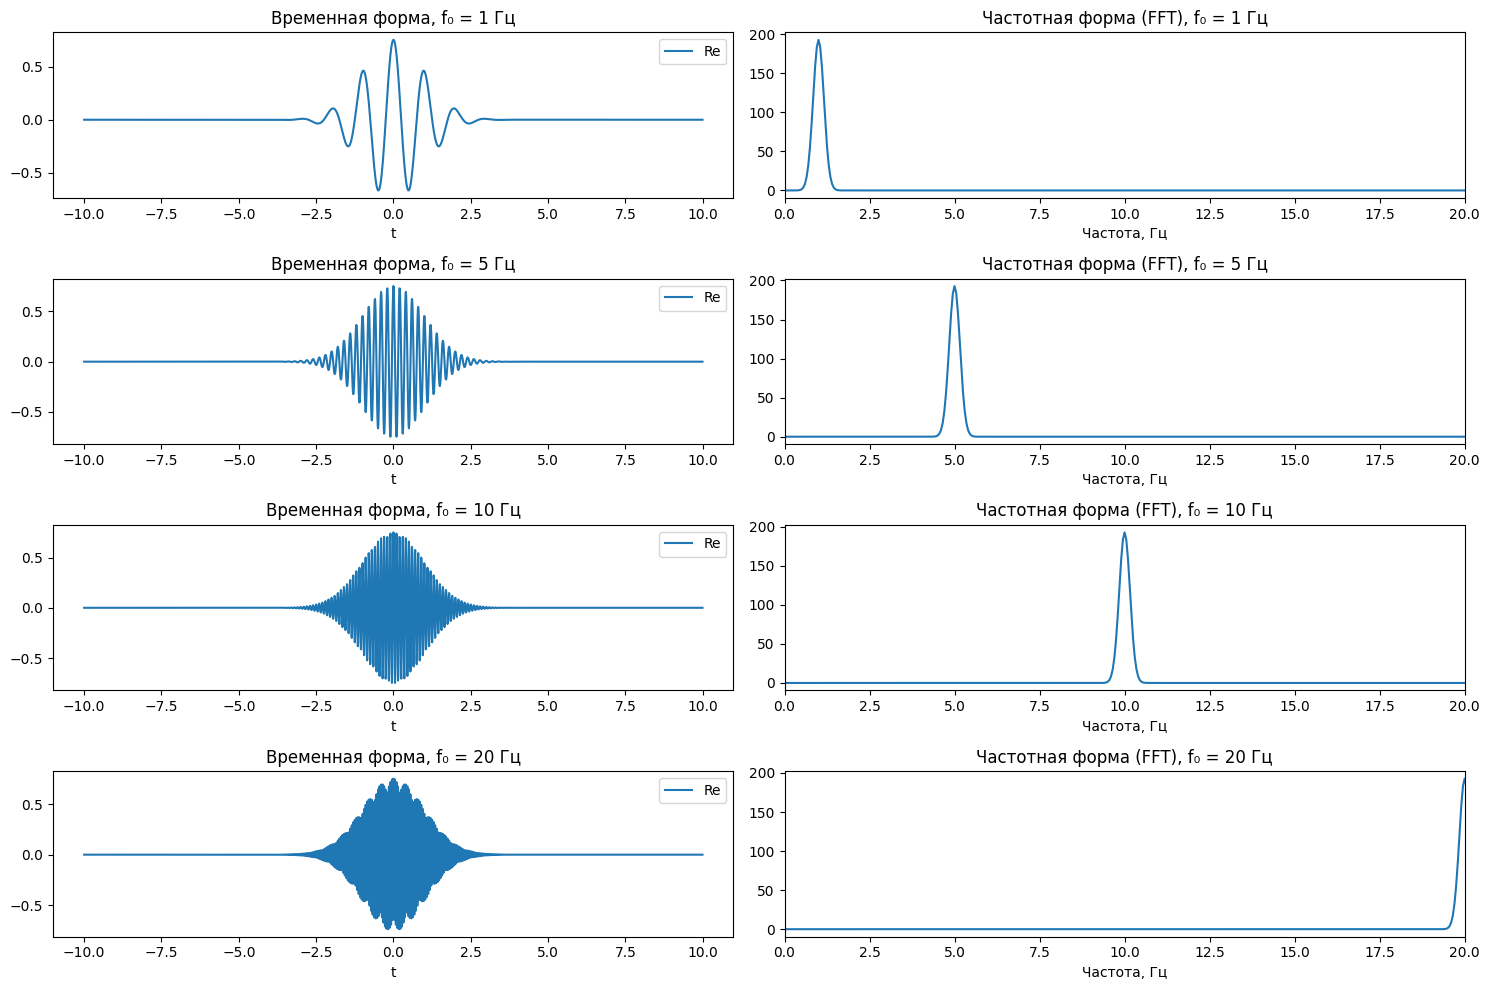

In [2]:
t = np.linspace(-10, 10, 2048, endpoint=False)
dt = t[1] - t[0]

def morlet_time(t, f0=5.0, sigma=1.0):
    
    norm = np.pi**(-0.25) / np.sqrt(sigma)
    gaussian = np.exp(-t**2 / (2 * sigma**2))
    complex_exp = np.exp(1j * 2 * np.pi * f0 * t)
    return norm * gaussian * complex_exp


f0_values = [1, 5, 10, 20]

fig, axs = plt.subplots(len(f0_values), 2, figsize=(15, 10)) #3
for i, f0 in enumerate(f0_values):
    psi = morlet_time(t, f0=f0, sigma=1.0)
    
    # Временная форма 
    axs[i, 0].plot(t, np.real(psi), label='Re')
    # axs[i, 0].plot(t, np.imag(psi), label='Im')
    # axs[i, 0].plot(t, np.abs(psi), '--', label='|ψ|')
    axs[i, 0].set_title(f'Временная форма, f₀ = {f0} Гц')
    axs[i, 0].set_xlabel('t')
    axs[i, 0].legend()
    
    # Частотная форма 
    psi_fft = fft(psi)
    freq = fftfreq(len(t), dt)
    idx = freq > 0
    axs[i, 1].plot(freq[idx], np.abs(psi_fft[idx]))
    axs[i, 1].set_title(f'Частотная форма (FFT), f₀ = {f0} Гц')
    axs[i, 1].set_xlabel('Частота, Гц')
    axs[i, 1].set_xlim(0, 20)
    
    # Теоретическая частотная форма 
    # gauss_freq = np.exp(-(freq - f0)**2 / 2)
    # axs[i, 2].plot(freq[idx], gauss_freq[idx], label='Теор. (сдвиг)')
    # axs[i, 2].set_title('Теоретическая частотная форма')
    # axs[i, 2].legend()

plt.tight_layout()
plt.show()

## Пункт 2

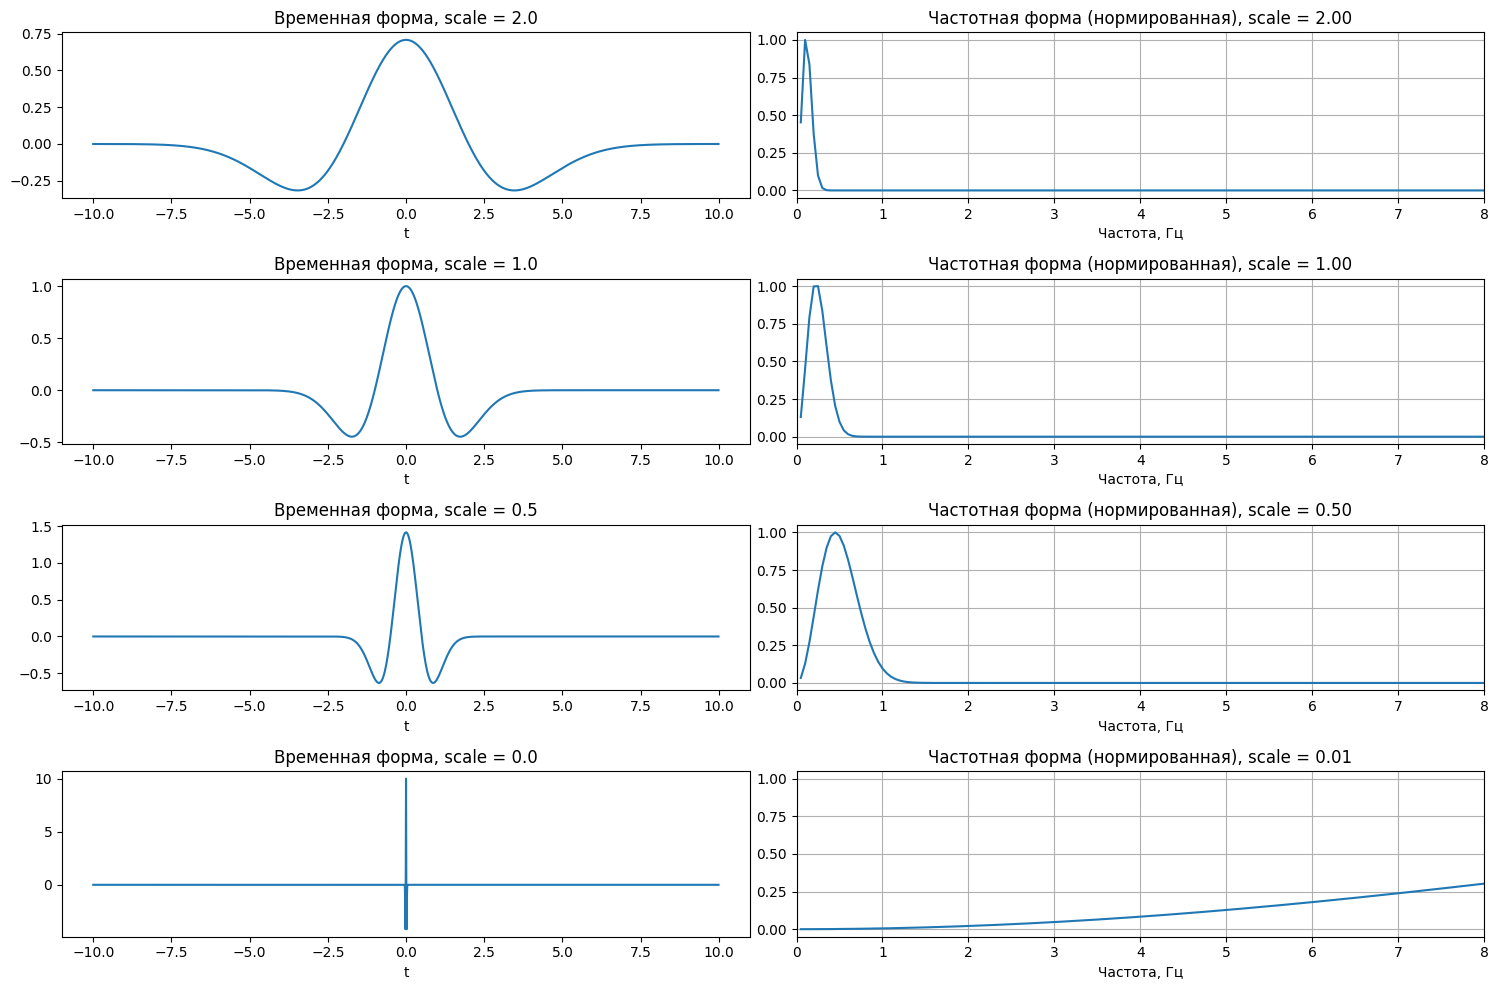

In [3]:
def mexican_hat_time(t, scale=1.0):
    
    t_scaled = t / scale
    psi = (2 / (np.sqrt(3 * np.pi**0.25))) * (1 - t_scaled**2) * np.exp(-t_scaled**2 / 2)
    return psi / np.sqrt(scale)  


scales = [2.0, 1.0, 0.5, 0.01]  

fig, axs = plt.subplots(len(scales), 2, figsize=(15, 10)) #3
for i, sc in enumerate(scales):
    psi = mexican_hat_time(t, scale=sc)
    
    axs[i, 0].plot(t, psi)
    axs[i, 0].set_title(f'Временная форма, scale = {sc:.1f}')
    axs[i, 0].set_xlabel('t')
    
    # Частотная форма
    psi_fft = fft(psi)
    freq = fftfreq(len(t), dt)
    idx = freq > 0
    # Нормируем амплитуду спектра для удобства сравнения (по максимуму)
    spectrum = np.abs(psi_fft[idx])
    spectrum = spectrum / np.max(spectrum)   # нормируем каждый спектр к 1
    
    axs[i, 1].plot(freq[idx], spectrum)
    axs[i, 1].set_title(f'Частотная форма (нормированная), scale = {sc:.2f}')
    axs[i, 1].set_xlabel('Частота, Гц')
    axs[i, 1].set_xlim(0, 8)
    axs[i, 1].grid(True)
    # Теоретический пик частоты 
    # f_peak = 0.8 / sc
    # axs[i, 2].axvline(f_peak, color='r', linestyle='--', label=f'Пик ≈ {f_peak:.1f} Гц')
    # axs[i, 2].set_title('Сдвиг центральной частоты')
    # axs[i, 2].legend()

plt.tight_layout()
plt.show()

## Пункт 3

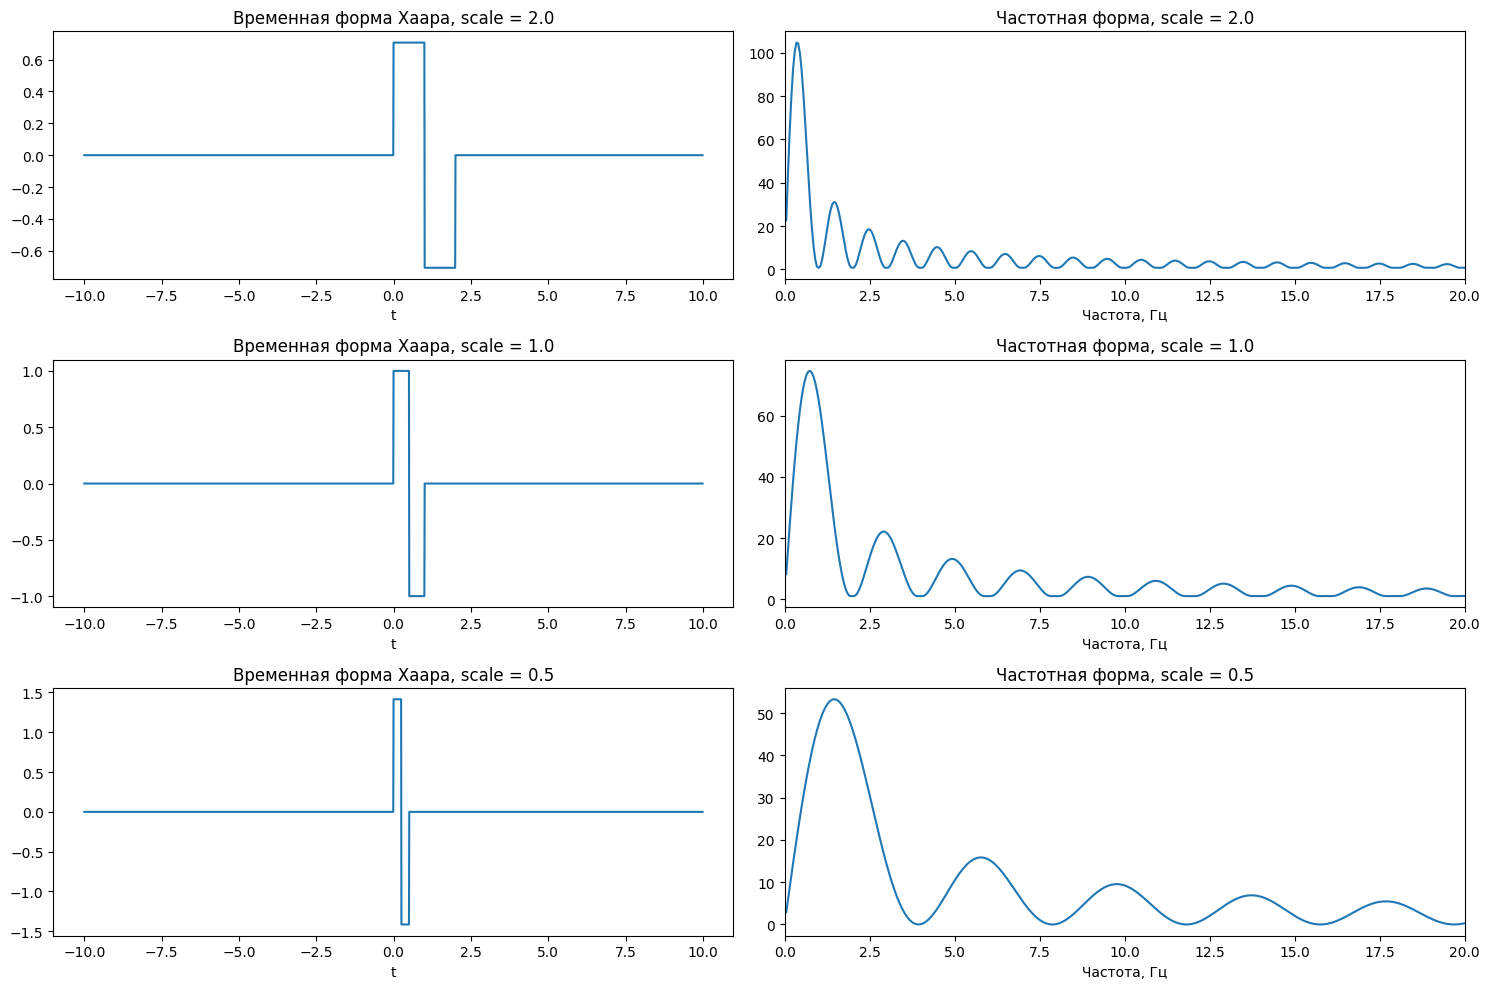

In [4]:
def haar_time(t, scale=1.0):
    
    psi = np.zeros_like(t)
    mask1 = (t >= 0) & (t < 0.5 * scale)
    mask2 = (t >= 0.5 * scale) & (t < 1.0 * scale)
    psi[mask1] = 1.0
    psi[mask2] = -1.0
    return psi / np.sqrt(scale)  

scales_haar = [2.0, 1.0, 0.5]

fig, axs = plt.subplots(len(scales_haar), 2, figsize=(15, 10)) #3
for i, sc in enumerate(scales_haar):
    psi = haar_time(t, scale=sc)
    
    axs[i, 0].plot(t, psi)
    axs[i, 0].set_title(f'Временная форма Хаара, scale = {sc:.1f}')
    axs[i, 0].set_xlabel('t')
    
    psi_fft = fft(psi)
    freq = fftfreq(len(t), dt)
    idx = freq > 0
    axs[i, 1].plot(freq[idx], np.abs(psi_fft[idx]))
    axs[i, 1].set_title(f'Частотная форма, scale = {sc:.1f}')
    axs[i, 1].set_xlabel('Частота, Гц')
    axs[i, 1].set_xlim(0, 20)
    
    # Центральная частота 
    # f_c = 0.5 / sc
    # axs[i, 2].axvline(f_c, color='r', linestyle='--', label=f'Центр ≈ {f_c:.1f} Гц')
    # axs[i, 2].legend()

plt.tight_layout()
plt.show()

## Пункт 4

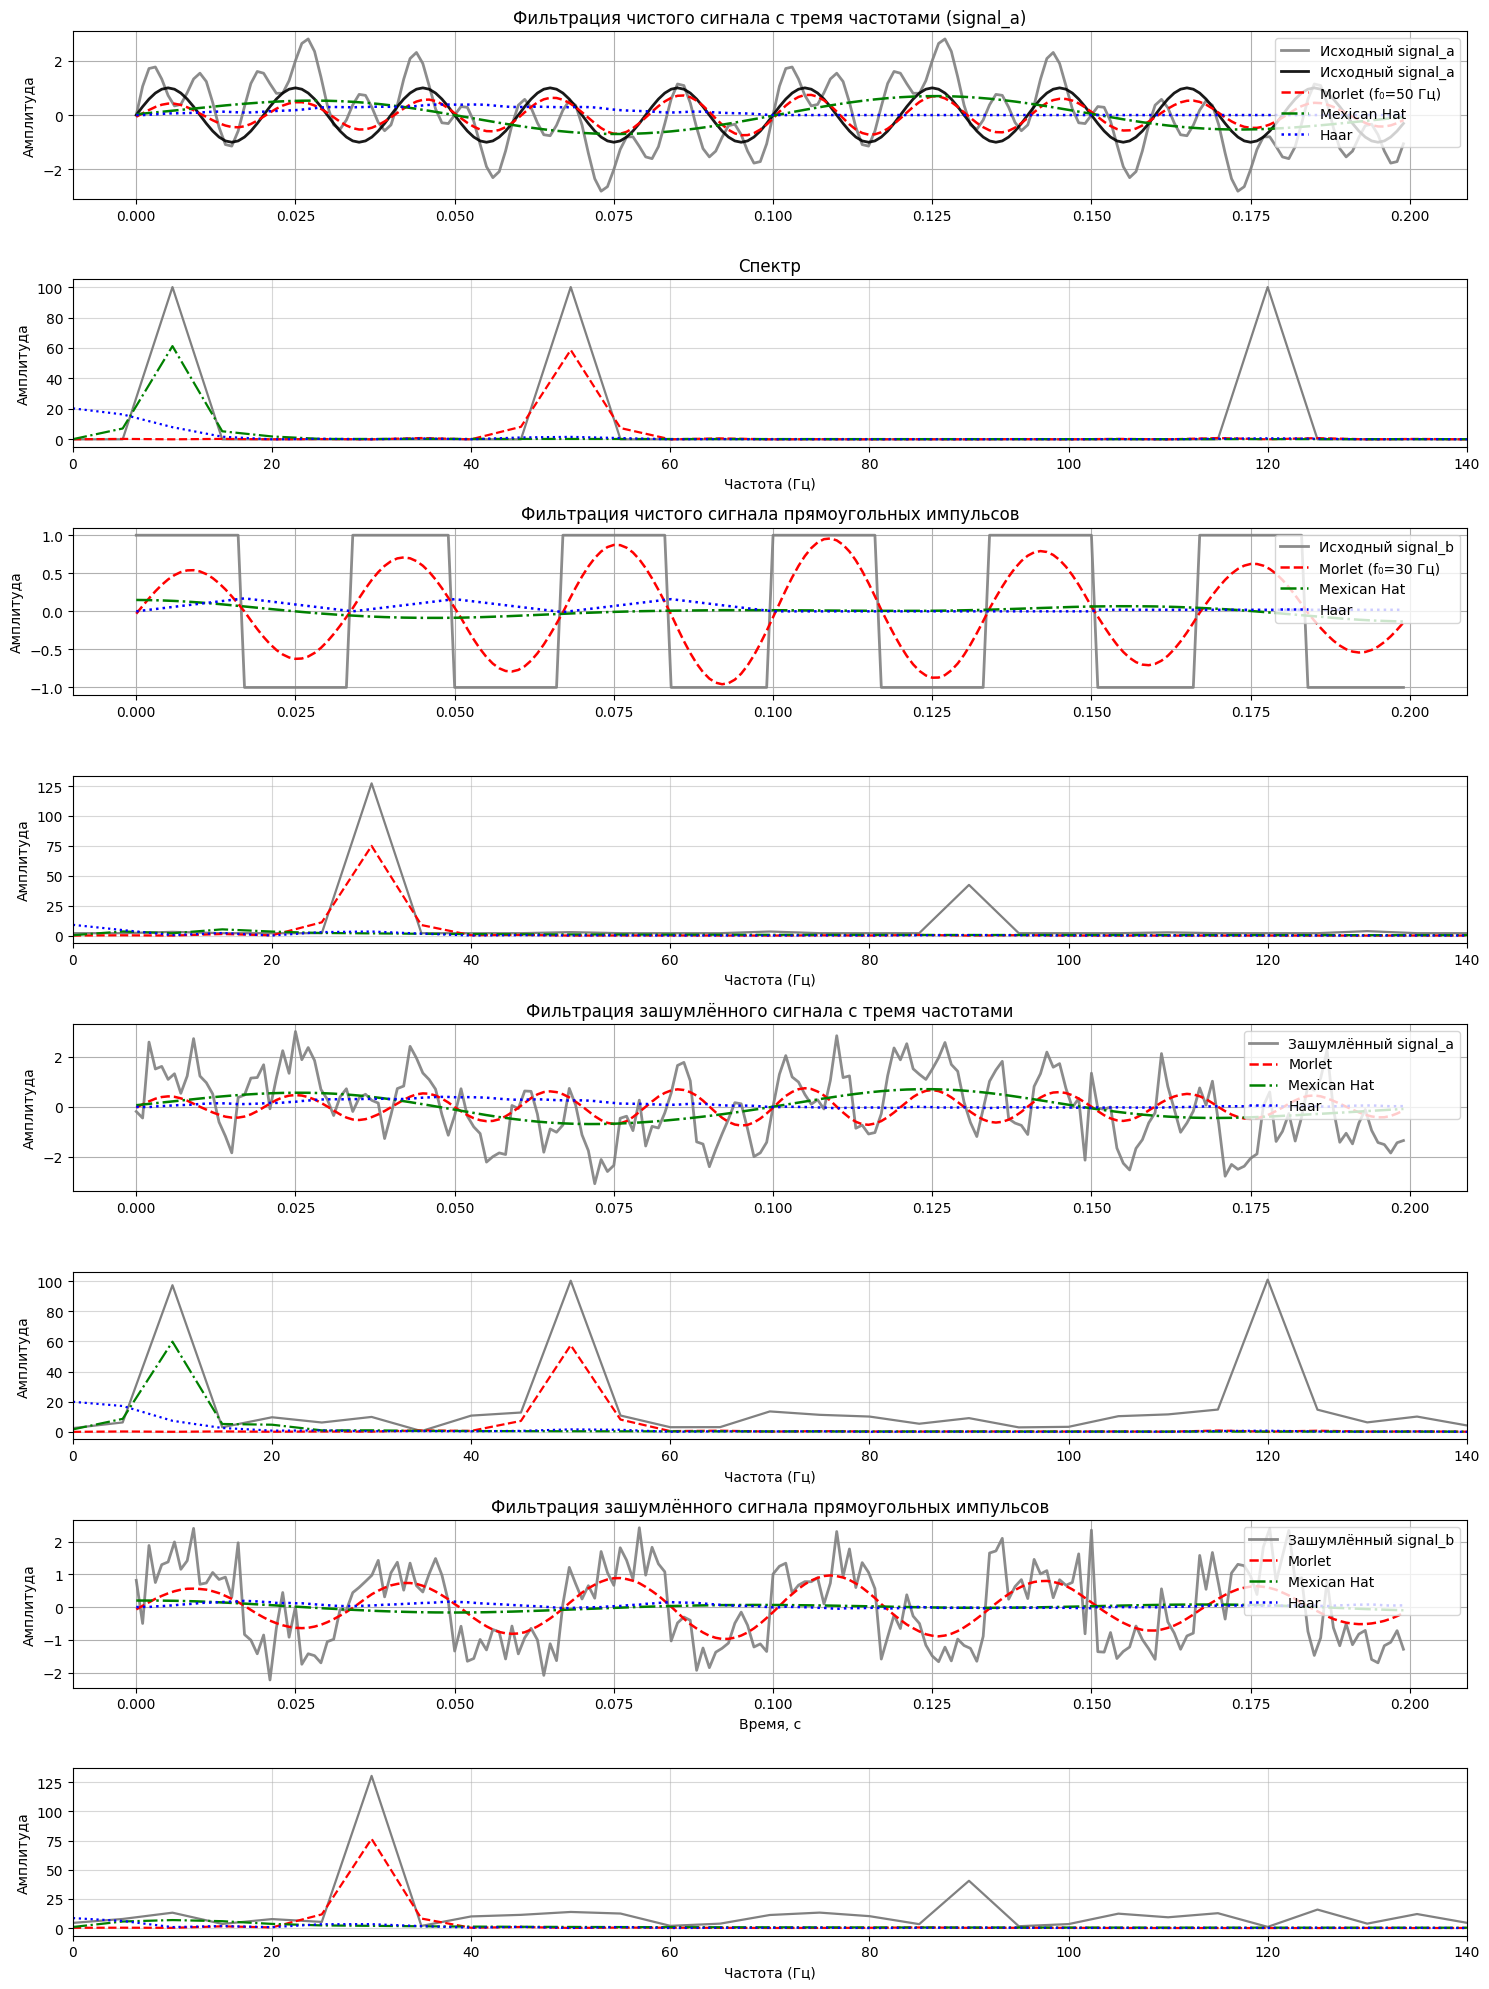

In [18]:
fs = 1000
t_sig = np.arange(0, 0.2, 1/fs)

signal_a = (np.sin(2*np.pi*10*t_sig) + 
            np.sin(2*np.pi*50*t_sig) + 
            np.sin(2*np.pi*120*t_sig))

signal_clean = (0*np.sin(2*np.pi*10*t_sig) + 
            np.sin(2*np.pi*50*t_sig) + 
            0*np.sin(2*np.pi*120*t_sig))

signal_b = sig.square(2*np.pi*30*t_sig)

noise = 0.6 * np.random.randn(len(t_sig))
signal_a_noisy = signal_a + noise
signal_b_noisy = signal_b + noise

def wavelet_convolve(signal_data, wavelet_func, param, is_morlet=False):
    t_wave = t_sig - t_sig.mean()
    wav = wavelet_func(t_wave, param)
    
    if is_morlet:
        wav = np.real(wav)
    
    wav = wav / np.sum(np.abs(wav))
    
    conv_result = sig.convolve(signal_data, wav, mode='same')
    
    orig_max = np.max(np.abs(signal_data))
    conv_max = np.max(np.abs(conv_result))
    
    # if conv_max > 0:
    #     scaling_factor = orig_max / conv_max * 0.92   
    #     conv_result *= scaling_factor
    
    
    
    return conv_result


conv_mor_a  = wavelet_convolve(signal_a, morlet_time, 50, is_morlet=True)
conv_mex_a  = wavelet_convolve(signal_a, mexican_hat_time, 0.018)
conv_haar_a = wavelet_convolve(signal_a, haar_time, 0.38)

conv_mor_b  = wavelet_convolve(signal_b, morlet_time, 30, is_morlet=True)
conv_mex_b  = wavelet_convolve(signal_b, mexican_hat_time, 0.028)
conv_haar_b = wavelet_convolve(signal_b, haar_time, 0.55)

conv_mor_a_noisy  = wavelet_convolve(signal_a_noisy, morlet_time, 50, is_morlet=True)
conv_mex_a_noisy  = wavelet_convolve(signal_a_noisy, mexican_hat_time, 0.018)
conv_haar_a_noisy = wavelet_convolve(signal_a_noisy, haar_time, 0.38)

conv_mor_b_noisy  = wavelet_convolve(signal_b_noisy, morlet_time, 30, is_morlet=True)
conv_mex_b_noisy  = wavelet_convolve(signal_b_noisy, mexican_hat_time, 0.028)
conv_haar_b_noisy = wavelet_convolve(signal_b_noisy, haar_time, 0.55)


fig, axs = plt.subplots(8, 1, figsize=(15, 20))


def plot_spectrum(ax, signal, label, color, linestyle='-'):
    N = len(signal)
    spectrum = np.abs(fft(signal)[:N//2])
    freq = fftfreq(N, 1/fs)[:N//2]
    ax.plot(freq, spectrum, color=color, linestyle=linestyle, linewidth=1.6, label=label)
    ax.set_xlim(0, 140)
    ax.set_xlabel('Частота (Гц)')
    ax.set_ylabel('Амплитуда')
    ax.grid(True, alpha=0.5)

# 1. Чистый signal_a
axs[0].plot(t_sig, signal_a,      'gray', alpha=0.9, linewidth=2.0, label='Исходный signal_a')
axs[0].plot(t_sig, signal_clean,      'black', alpha=0.9, linewidth=2.0, label='Исходный signal_a')
axs[0].plot(t_sig, conv_mor_a,   'red',   linewidth=1.8, label='Morlet (f₀=50 Гц)', linestyle='--')
axs[0].plot(t_sig, conv_mex_a,   'green', linewidth=1.8, label='Mexican Hat', linestyle='-.')
axs[0].plot(t_sig, conv_haar_a,  'blue',  linewidth=1.8, label='Haar', linestyle='dotted')
axs[0].set_title('Фильтрация чистого сигнала с тремя частотами (signal_a)')
axs[0].set_ylabel('Амплитуда')
axs[0].legend(loc='upper right')
axs[0].grid(True)

plot_spectrum(axs[1], signal_a,      'Исходный', 'gray')
plot_spectrum(axs[1], conv_mor_a,   'Morlet', 'red', '--')
plot_spectrum(axs[1], conv_mex_a,   'Mexican Hat', 'green', '-.')
plot_spectrum(axs[1], conv_haar_a,  'Haar', 'blue', 'dotted')
axs[1].set_title('Спектр')

# 2. Чистый signal_b
axs[2].plot(t_sig, signal_b,      'gray', alpha=0.9, linewidth=2.0, label='Исходный signal_b')
axs[2].plot(t_sig, conv_mor_b,   'red',   linewidth=1.8, label='Morlet (f₀=30 Гц)', linestyle='--')
axs[2].plot(t_sig, conv_mex_b,   'green', linewidth=1.8, label='Mexican Hat', linestyle='-.')
axs[2].plot(t_sig, conv_haar_b,  'blue',  linewidth=1.8, label='Haar', linestyle='dotted')
axs[2].set_title('Фильтрация чистого сигнала прямоугольных импульсов')
axs[2].set_ylabel('Амплитуда')
axs[2].legend(loc='upper right')
axs[2].grid(True)

plot_spectrum(axs[3], signal_b,      'Исходный', 'gray')
plot_spectrum(axs[3], conv_mor_b,   'Morlet', 'red', '--')
plot_spectrum(axs[3], conv_mex_b,   'Mexican Hat', 'green', '-.')
plot_spectrum(axs[3], conv_haar_b,  'Haar', 'blue', 'dotted')

# 3. Зашумлённый signal_a
axs[4].plot(t_sig, signal_a_noisy, 'gray', alpha=0.9, linewidth=2.0, label='Зашумлённый signal_a')
axs[4].plot(t_sig, conv_mor_a_noisy,  'red',   linewidth=1.8, label='Morlet', linestyle='--')
axs[4].plot(t_sig, conv_mex_a_noisy,  'green', linewidth=1.8, label='Mexican Hat', linestyle='-.')
axs[4].plot(t_sig, conv_haar_a_noisy, 'blue',  linewidth=1.8, label='Haar', linestyle='dotted')
axs[4].set_title('Фильтрация зашумлённого сигнала с тремя частотами')
axs[4].set_ylabel('Амплитуда')
axs[4].legend(loc='upper right')
axs[4].grid(True)

plot_spectrum(axs[5], signal_a_noisy, 'Исходный', 'gray')
plot_spectrum(axs[5], conv_mor_a_noisy, 'Morlet', 'red', '--')
plot_spectrum(axs[5], conv_mex_a_noisy, 'Mexican Hat', 'green', '-.')
plot_spectrum(axs[5], conv_haar_a_noisy, 'Haar', 'blue', 'dotted')

# 4. Зашумлённый signal_b
axs[6].plot(t_sig, signal_b_noisy, 'gray', alpha=0.9, linewidth=2.0, label='Зашумлённый signal_b')
axs[6].plot(t_sig, conv_mor_b_noisy,  'red',   linewidth=1.8, label='Morlet', linestyle='--')
axs[6].plot(t_sig, conv_mex_b_noisy,  'green', linewidth=1.8, label='Mexican Hat', linestyle='-.')
axs[6].plot(t_sig, conv_haar_b_noisy, 'blue',  linewidth=1.8, label='Haar', linestyle='dotted')
axs[6].set_title('Фильтрация зашумлённого сигнала прямоугольных импульсов')
axs[6].set_xlabel('Время, с')
axs[6].set_ylabel('Амплитуда')
axs[6].legend(loc='upper right')
axs[6].grid(True)

plot_spectrum(axs[7], signal_b_noisy, 'Исходный', 'gray')
plot_spectrum(axs[7], conv_mor_b_noisy, 'Morlet', 'red', '--')
plot_spectrum(axs[7], conv_mex_b_noisy, 'Mexican Hat', 'green', '-.')
plot_spectrum(axs[7], conv_haar_b_noisy, 'Haar', 'blue', 'dotted')

plt.tight_layout()
plt.show()

## Пункт 5

Нормы вейвлетов: min=0.0568, max=0.2539, mean=0.1759
=== ДЕБАГ: АМПЛИТУДА ВЕЙВЛЕТОВ (np.abs) ДЛЯ t < 0 ===
Частота 5.0 Гц | max amp (t<0): 0.0046 | mean amp (t<0): 0.0003 | min amp (t<0): 0.000000
Частота 53.1 Гц | max amp (t<0): 0.0484 | mean amp (t<0): 0.0003 | min amp (t<0): 0.000000
Частота 100.0 Гц | max amp (t<0): 0.0912 | mean amp (t<0): 0.0004 | min amp (t<0): 0.000000


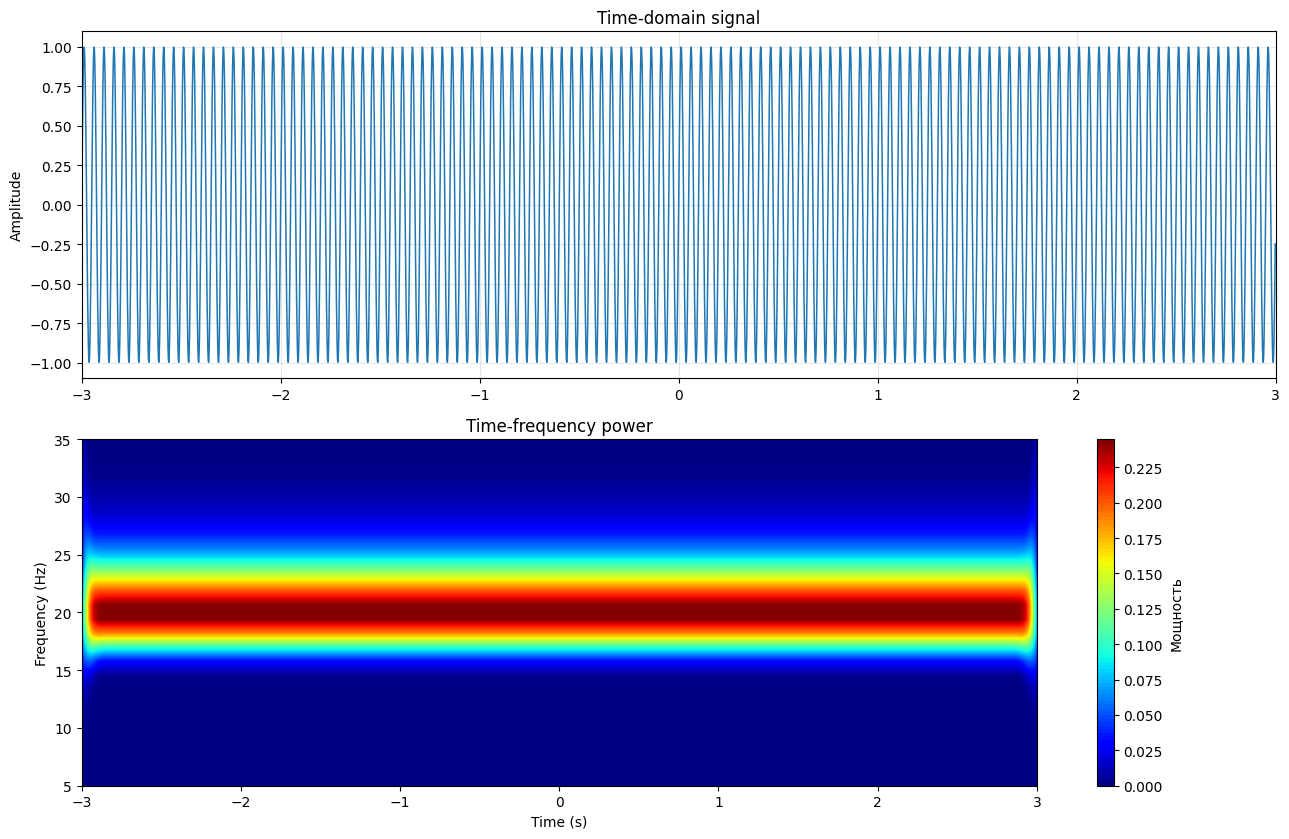

In [ ]:
srate = 500
time = np.arange(-3, 3, 1/srate)
n = len(time)


freqmod = 11 + 15 * np.exp(-(time / 1.2)**2)

phase = time + np.cumsum(freqmod) / srate
#signal = np.sin(2 * np.pi * phase)
signal = np.sin(40 * np.pi*time)
frex = np.linspace(5, 100, 80)


wavelets = np.zeros((len(frex), n), dtype=complex)
cycles = 5.5          

for wi in range(len(frex)):
    
    sigma = cycles / (2 * np.pi * frex[wi])      
    # sigma = cycles / frex[wi]                  
    gaussian = np.exp(-time**2 / (2 * sigma**2))
    norm_factor = np.sum(gaussian)
    wavelets[wi, :] = np.exp(1j * 2 * np.pi * frex[wi] * time) * gaussian / norm_factor

norms = np.array([np.sqrt(np.sum(np.abs(wavelets[wi, :])**2)) for wi in range(len(frex))])
print(f"Нормы вейвлетов: min={norms.min():.4f}, max={norms.max():.4f}, mean={norms.mean():.4f}")


print("=== ДЕБАГ: АМПЛИТУДА ВЕЙВЛЕТОВ (np.abs) ДЛЯ t < 0 ===")
left_mask = time < 0
for idx in [0, len(frex)//2, -1]:               
    amp_left = np.abs(wavelets[idx, left_mask])
    print(f"Частота {frex[idx]:.1f} Гц | "
          f"max amp (t<0): {np.max(amp_left):.4f} | "
          f"mean amp (t<0): {np.mean(amp_left):.4f} | "
          f"min amp (t<0): {np.min(amp_left):.6f}")


nconv = n * 2 - 1
sigX = scipy.fftpack.fft(signal, nconv)
tf = np.zeros((len(frex), n))

tf_plot = np.log10(tf + 1e-10)

for fi in range(len(frex)):
    waveX = scipy.fftpack.fft(wavelets[fi, :], nconv)
    convres = scipy.fftpack.ifft(waveX * sigX)
    
    start = nconv//2 - n//2
    tf[fi, :] = np.abs(convres[start : start + n])**2


fig, axs = plt.subplots(2, 1, figsize=(13, 8.5))

axs[0].plot(time, signal, color='#1f77b4', linewidth=1.1)
axs[0].set_title('Time-domain signal')
axs[0].set_ylabel('Amplitude')
axs[0].set_xlim(-3, 3)
axs[0].grid(True, alpha=0.3)

im = axs[1].contourf(time, frex, tf, levels=120, cmap='jet')
axs[1].set_title('Time-frequency power')
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Frequency (Hz)')
axs[1].set_xlim(-3, 3)
axs[1].set_ylim(5, 35)
fig.colorbar(im, ax=axs[1], label='Мощность')

plt.tight_layout()
plt.show()

## Пункт 6

C:\Users\Kamen\AppData\Local\Temp\ipykernel_3616\3389132572.py:15: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_note, data_note = wavfile.read(BytesIO(response_note.content))


Скачана реальная нота 440 Гц: 10.0 сек, fs = 44100 Гц
Скачано любое аудио: 5.0 сек, fs = 16000 Гц
=== РЕАЛЬНАЯ СКАЧАННАЯ НОТА 440 Гц (проверка алгоритма) ===


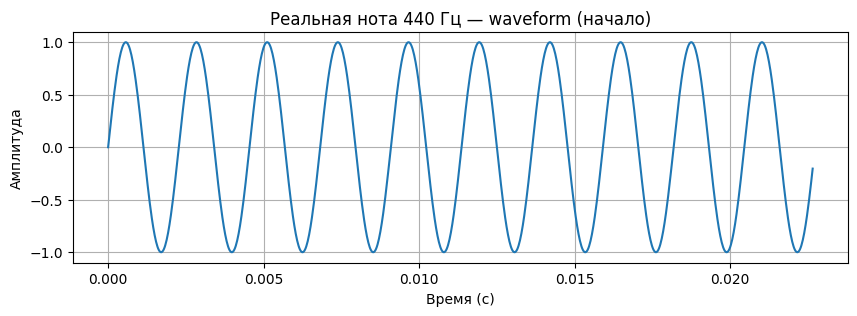

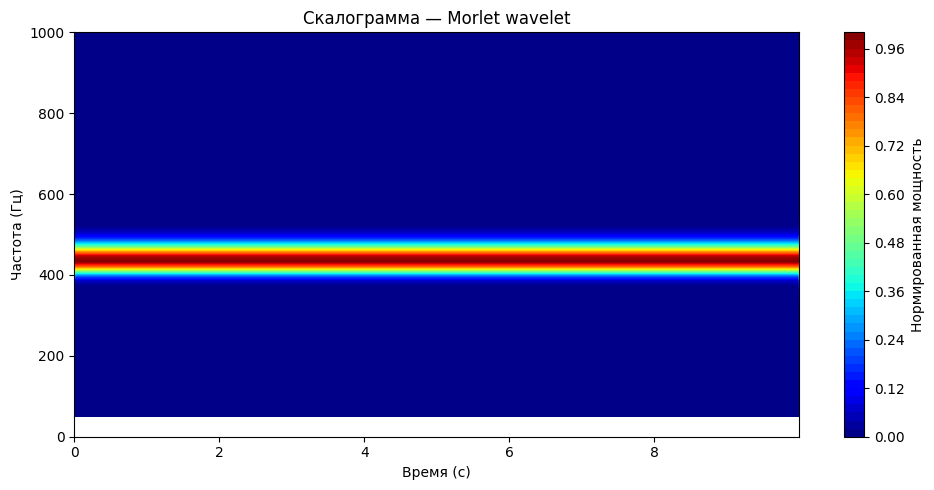

KeyboardInterrupt: 

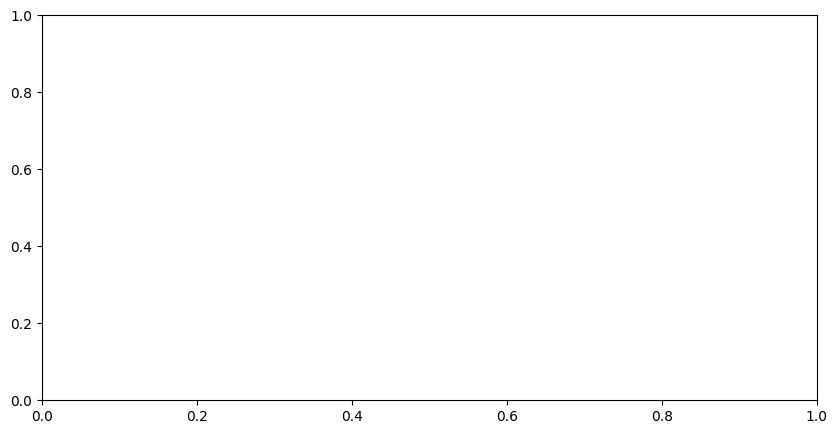

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import requests
from io import BytesIO
from scipy.fft import fft, ifft, next_fast_len   # ← нужно для твоей версии функции
from scipy.io.wavfile import write as wav_write

# ========== 1. РЕАЛЬНАЯ СКАЧАННАЯ НОТА "ЛЯ" (440 Гц) вместо синтетической ==========
# Теперь вместо генерации np.sin() скачиваем настоящий WAV-файл тона 440 Гц
# Это именно "скачанный реальный звук", как ты просил. На графике будет чётко видно 440 Гц,
# но уже не идеально-математическая синусоида, а реальный аудиофайл (с лёгкими особенностями записи).
url_note = "https://www.mediacollege.com/audio/tone/files/440Hz_44100Hz_16bit_30sec.wav"
response_note = requests.get(url_note, timeout=10)
fs_note, data_note = wavfile.read(BytesIO(response_note.content))

# Приводим к моно и нормализуем
if len(data_note.shape) > 1:
    data_note = np.mean(data_note, axis=1)
data_note = data_note.astype(np.float64)
data_note /= np.max(np.abs(data_note)) + 1e-8

# Берём первые 10 секунд (достаточно для красивой скалограммы)
real_note = data_note[:int(fs_note * 10)]

print(f"Скачана реальная нота 440 Гц: {len(real_note)/fs_note:.1f} сек, fs = {fs_note} Гц")

# ========== 2. Скачивание любого аудио (оставляем как было) ==========
url_any = "https://github.com/rafaelreis-hotmart/Audio-Sample-files/raw/master/sample.wav"
response_any = requests.get(url_any, timeout=10)
fs_any, data_any = wavfile.read(BytesIO(response_any.content))

if len(data_any.shape) > 1:
    data_any = np.mean(data_any, axis=1)
data_any = data_any.astype(np.float64)
data_any /= np.max(np.abs(data_any)) + 1e-8

any_audio = data_any[:int(fs_any * 5)]   # 5 секунд, как у тебя

print(f"Скачано любое аудио: {len(any_audio)/fs_any:.1f} сек, fs = {fs_any} Гц")

# ========== 3. Вейвлеты (твои версии с нормировкой) ==========
def mexican_hat_time(t_samples, scale):
    t_norm = t_samples / scale
    psi = (1 - t_norm**2) * np.exp(-0.5 * t_norm**2)
    norm_const = 2 / (np.sqrt(3) * np.pi**0.25)   
    return norm_const * psi / np.sqrt(scale)      

def haar_time(t_samples, scale):
    t_norm = t_samples / scale
    wave = np.zeros_like(t_samples, dtype=float)
    wave[(t_norm >= 0) & (t_norm < 0.5)] = 1.0
    wave[(t_norm >= 0.5) & (t_norm < 1.0)] = -1.0
    return wave / np.sqrt(scale)

# ========== 4. Функция скалограммы (твоя версия без изменений) ==========
def build_spectrogram(signal, fs, wavelet_name="Morlet", n_frex=80, max_freq=1000, custom=False):
    n = len(signal)
    time = np.arange(n) / fs
    frex = np.linspace(50, max_freq, n_frex)
    
    t_centered = (np.arange(n) - n//2) / fs          
    t_samples = t_centered * fs
    
    tf = np.zeros((len(frex), n))
    
    nconv = n * 2 - 1
    nconv_fast = next_fast_len(nconv) 
    sigX = fft(signal, nconv_fast)
    
    for fi, f in enumerate(frex):
        if wavelet_name == "Morlet":
            sigma_sec = 2.0 / f                      
            g = np.exp(-t_centered**2 / (2 * sigma_sec**2))
            wave = np.exp(1j * 2 * np.pi * f * t_centered) * g
        elif wavelet_name == "MexicanHat":
            scale = 0.2516 * fs / f                 
            wave = mexican_hat_time(t_samples, scale)
        elif wavelet_name == "Haar":
            scale = fs / f                           
            wave = haar_time(t_samples, scale)
        
        waveX = fft(wave, nconv_fast)
        convres = ifft(waveX * sigX)
        
        half_wave = n // 2
        tf[fi, :] = np.abs(convres[half_wave : half_wave + n]) ** 2
    
    if not custom:
        tf = tf / np.max(tf)
    else:
        tf = 10 * np.log10(tf + 1e-9)
    
    plt.figure(figsize=(10, 5))
    plt.contourf(time, frex, tf, levels=60, cmap='jet')
    plt.colorbar(label='Нормированная мощность' if not custom else 'Мощность (дБ)')
    plt.xlabel('Время (с)')
    plt.ylabel('Частота (Гц)')
    plt.title(f'Скалограмма — {wavelet_name} wavelet')
    plt.ylim(0, max_freq)
    plt.tight_layout()
    plt.show()

def plot_waveform(signal, fs, title):
    plt.figure(figsize=(10, 3))
    plt.plot(np.arange(len(signal[:1000]))/fs, signal[:1000])
    plt.title(title)
    plt.xlabel('Время (с)')
    plt.ylabel('Амплитуда')
    plt.grid(True)
    plt.show()

# ========== 5. Запуск ==========
print("=== РЕАЛЬНАЯ СКАЧАННАЯ НОТА 440 Гц (проверка алгоритма) ===")
plot_waveform(real_note, fs_note, "Реальная нота 440 Гц — waveform (начало)")
build_spectrogram(real_note, fs_note, "Morlet", custom=False)
build_spectrogram(real_note, fs_note, "MexicanHat", custom=False)
build_spectrogram(real_note, fs_note, "Haar", custom=False)

print("=== ЛЮБОЕ СКАЧАННОЕ АУДИО ===")
plot_waveform(any_audio, fs_any, "Скачанное аудио — waveform (начало)")

build_spectrogram(any_audio, fs_any, "Morlet", max_freq=1000, custom=True)
build_spectrogram(any_audio, fs_any, "MexicanHat", max_freq=1000, custom=True)
build_spectrogram(any_audio, fs_any, "Haar", max_freq=1000, custom=True)

# ========== 6. Сохраняем файлы для прослушивания ==========
wav_write("real_note_440.wav", fs_note, (real_note * 32767).astype(np.int16))
wav_write("any_audio.wav", fs_any, (any_audio * 32767).astype(np.int16))
print("\nГотово! Файлы сохранены:")
print("• real_note_440.wav     — скачанная реальная нота 440 Гц (проверка)")
print("• any_audio.wav         — любое скачанное аудио")
print("Теперь на скалограмме чистой ноты ты видишь именно скачанный звук, а не синтетику.")

Ошибка загрузки: File format b'<!DO' not understood. Only 'RIFF', 'RIFX', and 'RF64' supported.. Проверьте интернет.
Анализ чистой синусоиды...


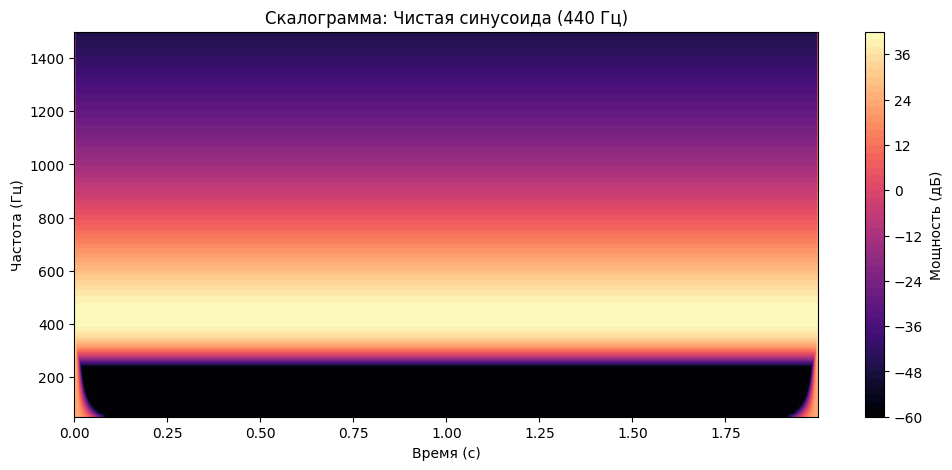

Анализ реального пианино...


NameError: name 'fs_real' is not defined

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import requests
from scipy.io import wavfile
from io import BytesIO
from scipy.fft import fft, ifft, next_fast_len

# 1. ПАРАМЕТРЫ И ГЕНЕРАЦИЯ ЧИСТОЙ НОТЫ (440 Гц)
fs = 44100
dur = 2.0
t = np.arange(0, dur, 1/fs)
pure_note = np.sin(2 * np.pi * 440 * t)

# 2. ЗАГРУЗКА РЕАЛЬНОГО ЗВУКА (Пианино, нота A4 - 440 Гц)
# Используем открытый архив звуков
url = "https://theremin.music.uiowa.edu/sound%20files/MIS/Piano_Notes/piano/Piano.ff.A4.wav"
try:
    response = requests.get(url, timeout=15)
    fs_real, data_real = wavfile.read(BytesIO(response.content))
    
    # Превращаем в моно и нормализуем
    if len(data_real.shape) > 1:
        data_real = np.mean(data_real, axis=1)
    real_note = data_real.astype(np.float64)
    real_note /= np.max(np.abs(real_note)) + 1e-8
    
    # Обрезаем до 2 секунд, чтобы сравнение было честным
    real_note = real_note[:int(fs_real * dur)]
    t_real = np.arange(len(real_note)) / fs_real
except Exception as e:
    print(f"Ошибка загрузки: {e}. Проверьте интернет.")
    real_note = pure_note # Фолбек

# 3. ФУНКЦИИ ВЕЙВЛЕТОВ
def build_spectrogram(signal, fs, title, wavelet_name="Morlet", max_freq=1500):
    n = len(signal)
    time = np.arange(n) / fs
    frex = np.linspace(50, max_freq, 100) # Увеличим диапазон, чтобы увидеть гармоники
    t_centered = (np.arange(n) - n//2) / fs
    
    tf = np.zeros((len(frex), n))
    nconv_fast = next_fast_len(n * 2 - 1) 
    sigX = fft(signal, nconv_fast)
    
    for fi, f in enumerate(frex):
        # Используем Morlet для лучшего частотного разрешения
        sigma_sec = 6.0 / (2 * np.pi * f) # Параметр ширины (6 циклов)
        g = np.exp(-t_centered**2 / (2 * sigma_sec**2))
        wave = np.exp(1j * 2 * np.pi * f * t_centered) * g
        
        waveX = fft(wave, nconv_fast)
        convres = ifft(waveX * sigX)
        half_wave = n // 2
        tf[fi, :] = np.abs(convres[half_wave : half_wave + n]) ** 2

    # Логарифмическая шкала (в децибелах), чтобы увидеть тихие гармоники
    tf_db = 10 * np.log10(tf + 1e-6)
    
    plt.figure(figsize=(12, 5))
    plt.contourf(time, frex, tf_db, levels=50, cmap='magma')
    plt.colorbar(label='Мощность (дБ)')
    plt.title(title)
    plt.ylabel('Частота (Гц)')
    plt.xlabel('Время (с)')
    plt.ylim(50, max_freq)
    plt.show()

# 4. ВИЗУАЛИЗАЦИЯ
print("Анализ чистой синусоиды...")
build_spectrogram(pure_note, fs, "Скалограмма: Чистая синусоида (440 Гц)")

print("Анализ реального пианино...")
build_spectrogram(real_note, fs_real, "Скалограмма: Реальное пианино (A4)")